# SRGCD: Stability-Driven Region Growth for 3D Change Detection
Colab-ready PyTorch implementation. Modules: KPConv-FPN · MGCP · SGCA (SAP+SPT) · BCE+CBL Loss · mIoU/Dice Eval.

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
!pip install open3d scikit-learn scipy tqdm matplotlib -q

In [1]:
import os, sys
if not os.path.exists('KPConv'):
    os.system('git clone https://github.com/HuguesTHOMAS/KPConv-PyTorch.git.git')
sys.path.insert(0, 'KPConv')
print('Setup complete.')

Setup complete.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from scipy.spatial import KDTree
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [3]:
def estimate_normals_pca(points, k=20):
    tree = KDTree(points)
    normals = np.zeros_like(points)
    for i, p in enumerate(points):
        _, idx = tree.query(p, k=k)
        nb = points[idx]
        centred = nb - nb.mean(0)
        cov = centred.T @ centred
        _, vecs = np.linalg.eigh(cov)
        normals[i] = vecs[:, 0]
    flip = (normals * (-points)).sum(-1) < 0
    normals[flip] *= -1
    return normals

def nn_difference_features(pts_t1, feats_t1, pts_t2, feats_t2, k=1):
    tree = KDTree(pts_t2)
    _, idx = tree.query(pts_t1, k=k)
    if k == 1:
        idx = idx.reshape(-1, 1)
    nn_feats = feats_t2[idx].mean(1)
    return feats_t1 - nn_feats

def preprocess_point_cloud(pts, rgb=None, k_normal=20):
    normals = estimate_normals_pca(pts, k=k_normal)
    parts = [pts, normals]
    if rgb is not None:
        parts.append(rgb)
    return np.concatenate(parts, axis=-1).astype(np.float32)

print('Preprocessing utilities ready.')

Preprocessing utilities ready.


Urb3DCD : Urban Point Clouds Simulated Dataset for 3D Change Detection: https://ieee-dataport.org/open-access/urb3dcd-urban-point-clouds-simulated-dataset-3d-change-detection , https://github.com/HuguesTHOMAS/KPConv-PyTorch, https://github.com/coledea/Multi-Temporal-Point-Cloud-Datasets?utm_source=copilot.com

In [10]:
# ============================================================
# CELL 5 — Dataset Loader: Urb3DCD
#
# Folder structure expected (matches your actual layout):
#   root_dir/
#     LyonN10/
#       pointCloud0.ply   (T1 — no labels needed)
#       pointCloud1.ply   (T2 — has label_ch field)
#     LyonN12/
#       ...
#
# Usage:
#   train_ds = ChangeDetectionDataset(
#       root_dir = "Urb3DCD_V1/IEEE_Dataset_V1/1-Lidar05/TrainNormal-1b",
#       num_points = 256
#   )
#   val_ds = ChangeDetectionDataset(
#       root_dir = "Urb3DCD_V1/IEEE_Dataset_V1/1-Lidar05/Val",
#       num_points = 256
#   )
# ============================================================

import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset
from plyfile import PlyData


# ── PLY loader consistent with Urb3DCD V1 field names ───────────────────
def load_ply_with_labels(path):
    """
    Load a Urb3DCD .ply file.
    Returns:
      pts    : (N, 3)  float32  xyz coordinates
      labels : (N,)   int64    binary {0=unchanged, 1=changed}

    Urb3DCD label_ch values:
      0 = unchanged
      1 = newlyBuilt
      2 = deconstructed
      3 = newVegetation
      4 = vegetationGrowUp
      5 = vegetationRemoved
      6 = mobileObjects
    All non-zero classes are collapsed to 1 for binary BCE loss.
    """
    ply   = PlyData.read(path)
    vert  = ply['vertex']
    pts   = np.vstack([vert[ax] for ax in ['x', 'y', 'z']]).T.astype(np.float32)

    # Discover label field — Urb3DCD V1 uses 'label_ch'
    props = [p.name for p in vert.properties]
    for field in ['label_ch', 'label', 'scalar_label', 'scalar_Label']:
        if field in props:
            labels = np.array(vert[field]).astype(np.int64)
            break
    else:
        # pointCloud0.ply has no labels in Urb3DCD — return zeros
        labels = np.zeros(len(pts), dtype=np.int64)

    # Binarise for BCE loss: 0=unchanged, 1=any change class
    labels = (labels > 0).astype(np.int64)
    return pts, labels


def load_ply_pts_only(path):
    """Load xyz only — used for pointCloud0.ply which has no labels."""
    ply = PlyData.read(path)
    pts = np.vstack([ply['vertex'][ax]
                     for ax in ['x', 'y', 'z']]).T.astype(np.float32)
    return pts


# ── Dataset ──────────────────────────────────────────────────────────────
class ChangeDetectionDataset(Dataset):
    """
    Urb3DCD dataset loader — fully consistent with SRGCD pipeline.

    Each scene folder contains:
      pointCloud0.ply  →  T1 (no labels in V1)
      pointCloud1.ply  →  T2 (has label_ch)

    Returns per sample:
      pts_t1 : (N, 3)   T1 xyz                          float32
      pts_t2 : (N, 3)   T2 xyz                          float32
      feats  : (N, 18)  [f1_6 | f2_6 | diff_6]         float32
               feats[:, :3]  = T1 xyz  ← used by KPConvFPN._branch()
               feats[:, 3:6] = T1 normals
               feats[:, 6:9] = T2 xyz
               feats[:, 9:12]= T2 normals
               feats[:,12:18]= nn diff
      labels : (N,)     binary int64 {0=unchanged, 1=changed}

    num_samples : max number of scene folders to load (None = all)
    num_points  : fixed point count per scene (random subsample)
    seed        : numpy random seed for reproducibility
    """

    def __init__(self, root_dir, num_samples=None, num_points=256, seed=42):
        super().__init__()
        rng = np.random.default_rng(seed)
        self.samples = []

        # Collect all scene folders that contain both ply files
        all_scenes = sorted([
            p for p in glob.glob(os.path.join(root_dir, '*'))
            if os.path.isdir(p)
            and os.path.exists(os.path.join(p, 'pointCloud0.ply'))
            and os.path.exists(os.path.join(p, 'pointCloud1.ply'))
        ])

        if len(all_scenes) == 0:
            raise FileNotFoundError(
                f"No valid scene folders found in: {root_dir}\n"
                f"Each folder must contain pointCloud0.ply and pointCloud1.ply"
            )

        # Limit number of scenes if requested
        if num_samples is not None:
            all_scenes = all_scenes[:num_samples]

        print(f"Loading {len(all_scenes)} scenes from {root_dir} ...")

        for scene in all_scenes:
            pc0_path = os.path.join(scene, 'pointCloud0.ply')
            pc1_path = os.path.join(scene, 'pointCloud1.ply')

            # T1: xyz only (no labels in Urb3DCD V1 pointCloud0)
            pc0       = load_ply_pts_only(pc0_path)

            # T2: xyz + labels
            pc1, lbl1 = load_ply_with_labels(pc1_path)

            # Subsample to fixed num_points from the safe minimum size
            safe_n = min(num_points, len(pc0), len(pc1))
            idx    = rng.choice(min(len(pc0), len(pc1)), safe_n, replace=False)
            p0, p1, lb = pc0[idx], pc1[idx], lbl1[idx]

            # ── Precompute features once (avoids slow KDTree in __getitem__)
            # preprocess_point_cloud returns [xyz | normals] → (N, 6)
            # feats[:,:3] = xyz  ← REQUIRED by KPConvFPN._branch() which
            #                      does pts = feats[:, :3]
            f1   = preprocess_point_cloud(p0)              # (N, 6)
            f2   = preprocess_point_cloud(p1)              # (N, 6)
            diff = nn_difference_features(p0, f1, p1, f2, k=1)  # (N, 6)
            feat = np.concatenate([f1, f2, diff], axis=-1).astype(np.float32)
            #      feat shape: (N, 18)
            #      feat[:, :6]   = f1  → SRGCD splits as feats[:,:,:6]
            #      feat[:, 6:12] = f2  → SRGCD splits as feats[:,:,6:12]
            #      feat[:,12:18] = diff

            self.samples.append((p0, p1, feat, lb))

        print(f"✅ {len(self.samples)} scenes ready. "
              f"Points per scene: {num_points}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        pts1, pts2, feat, labels = self.samples[idx]
        return {
            'pts_t1' : torch.from_numpy(pts1),    # (N, 3)   float32
            'pts_t2' : torch.from_numpy(pts2),    # (N, 3)   float32
            'feats'  : torch.from_numpy(feat),    # (N, 18)  float32
            'labels' : torch.from_numpy(labels),  # (N,)     int64
        }

ModuleNotFoundError: No module named 'plyfile'

In [11]:
!pip install plyfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.2 MB/s eta 0:00:00


In [12]:
# ============================================================
# CELL 5 — Dataset Loader: Urb3DCD V1
#
# Confirmed .ply structure (from diagnostic):
#   Element  : 'Urb3DSimul'
#   Fields   : x, y, z (float32), red, green, blue (uint8), label_ch (int8)
#   pc0 rows : ~165k  |  pc1 rows: ~161k  (differ per scene)
#
# Feature layout returned — (N, 18) consistent with SRGCD pipeline:
#   feat[:,  0: 3] = T1 xyz       ← KPConvFPN._branch() uses feat[:,:3] as pts
#   feat[:,  3: 6] = T1 normals
#   feat[:,  6: 9] = T2 xyz       ← SRGCD f2 = feats[:,:,6:12]
#   feat[:,  9:12] = T2 normals
#   feat[:, 12:18] = nn diff
#
# Labels: label_ch binarised → 0=unchanged, 1=any change class
# ============================================================

import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset
from plyfile import PlyData


# ============================================================
# CELL 5 — Dataset Loader: Urb3DCD V1  (Production Ready)
# ============================================================

import os, glob
import numpy as np
import torch
from torch.utils.data import Dataset
from plyfile import PlyData
from scipy.spatial import KDTree


def load_urb3d_ply(path):
    """Load Urb3DCD V1 .ply — element name confirmed as 'Urb3DSimul'."""
    ply    = PlyData.read(path)
    elem   = ply['Urb3DSimul']
    pts    = np.vstack([elem['x'], elem['y'],
                        elem['z']]).T.astype(np.float32)
    rgb    = np.vstack([elem['red'], elem['green'],
                        elem['blue']]).T.astype(np.float32) / 255.0
    labels = (np.array(elem['label_ch']).astype(np.int64) > 0).astype(np.int64)
    return pts, rgb, labels


def align_and_subsample(pc0, pc1, lbl1, num_points, rng):
    """
    Subsample pc0 randomly, then find nearest neighbour in pc1
    for each subsampled T1 point.
    Guarantees spatial correspondence between T1 and T2.
    """
    N    = min(num_points, len(pc0))
    idx0 = rng.choice(len(pc0), N, replace=False)
    p0   = pc0[idx0]

    # Each T1 point → closest T2 point (spatial alignment)
    tree = KDTree(pc1)
    _, idx1 = tree.query(p0, k=1)
    p1   = pc1[idx1]
    lb   = lbl1[idx1]
    return p0, p1, lb


def augment_sample(p0, p1, feat):
    """
    Random Z-axis rotation + small jitter.
    Applied consistently to both T1 and T2.
    """
    theta = np.random.uniform(0, 2 * np.pi)
    c, s  = np.cos(theta), np.sin(theta)
    R     = np.array([[c,-s,0],[s,c,0],[0,0,1]], dtype=np.float32)

    p0_aug = p0 @ R.T
    p1_aug = p1 @ R.T

    feat_aug = feat.copy()
    feat_aug[:, :3]  = p0_aug                   # T1 xyz
    feat_aug[:, 3:6] = feat[:, 3:6] @ R.T       # T1 normals
    feat_aug[:, 6:9] = p1_aug                   # T2 xyz
    feat_aug[:, 9:12]= feat[:, 9:12] @ R.T      # T2 normals

    # Small Gaussian jitter
    p0_aug += np.random.normal(0, 0.01, p0_aug.shape).astype(np.float32)
    p1_aug += np.random.normal(0, 0.01, p1_aug.shape).astype(np.float32)

    return p0_aug, p1_aug, feat_aug


class ChangeDetectionDataset(Dataset):
    """
    Urb3DCD V1 — production-ready dataset for SRGCD.

    Key improvements over basic version:
      1. Spatially aligned T1/T2 via nearest-neighbour matching
      2. num_points=4096 recommended (not 256)
      3. Bidirectional nn_difference_features
      4. Optional augmentation (enable for training, disable for val/test)
      5. pos_weight computed from actual label distribution

    Returns:
      pts_t1 : (N, 3)   float32
      pts_t2 : (N, 3)   float32
      feats  : (N, 18)  float32  consistent with SRGCD in_ch=6 backbone
      labels : (N,)     int64 binary
    """

    def __init__(self, root_dir, num_samples=None,
                 num_points=4096, augment=False, seed=42):
        super().__init__()
        rng = np.random.default_rng(seed)
        self.samples = []
        self.augment = augment

        all_scenes = sorted([
            p for p in glob.glob(os.path.join(root_dir, '*'))
            if os.path.isdir(p)
            and os.path.exists(os.path.join(p, 'pointCloud0.ply'))
            and os.path.exists(os.path.join(p, 'pointCloud1.ply'))
        ])
        if not all_scenes:
            raise FileNotFoundError(f"No scenes found in {root_dir}")
        if num_samples:
            all_scenes = all_scenes[:num_samples]

        print(f"Loading {len(all_scenes)} scenes | "
              f"num_points={num_points} | augment={augment}")

        total_pos, total_neg = 0, 0

        for scene in all_scenes:
            name = os.path.basename(scene)
            pc0, _, _    = load_urb3d_ply(os.path.join(scene, 'pointCloud0.ply'))
            pc1, _, lbl1 = load_urb3d_ply(os.path.join(scene, 'pointCloud1.ply'))

            # Spatially aligned subsample
            p0, p1, lb = align_and_subsample(pc0, pc1, lbl1, num_points, rng)

            # Bidirectional feature computation
            f1      = preprocess_point_cloud(p0)
            f2      = preprocess_point_cloud(p1)
            diff_12 = nn_difference_features(p0, f1, p1, f2, k=1)
            diff_21 = nn_difference_features(p1, f2, p0, f1, k=1)
            diff    = ((diff_12 + diff_21) / 2.0).astype(np.float32)
            feat    = np.concatenate([f1, f2, diff], axis=-1).astype(np.float32)

            total_pos += lb.sum()
            total_neg += (lb == 0).sum()

            self.samples.append({
                'p0': p0, 'p1': p1, 'feat': feat,
                'lb': lb, 'name': name
            })

        # Compute real pos_weight for BCELoss
        self.pos_weight = total_neg / max(total_pos, 1)
        print(f" {len(self.samples)} scenes | "
              f"change ratio: {total_pos/(total_pos+total_neg):.3f} | "
              f"recommended pos_weight: {self.pos_weight:.1f}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s  = self.samples[idx]
        p0, p1, feat = s['p0'], s['p1'], s['feat']

        if self.augment:
            p0, p1, feat = augment_sample(p0, p1, feat)

        return {
            'pts_t1': torch.from_numpy(p0.copy()),
            'pts_t2': torch.from_numpy(p1.copy()),
            'feats' : torch.from_numpy(feat.copy()),
            'labels': torch.from_numpy(s['lb']),
        }




In [13]:
# ============================================================
# DIAGNOSTIC — Run this BEFORE the dataset cell
# Inspects the actual structure of your .ply files
# ============================================================
from plyfile import PlyData
import os

# Pick one file from each cloud type
pc0_path = "Urb3DCD_V1/IEEE_Dataset_V1/1-Lidar05/TrainNormal-1b/LyonN10/pointCloud0.ply"
pc1_path = "Urb3DCD_V1/IEEE_Dataset_V1/1-Lidar05/TrainNormal-1b/LyonN10/pointCloud1.ply"

for path in [pc0_path, pc1_path]:
    print(f"\n{'='*60}")
    print(f"File: {os.path.basename(os.path.dirname(path))}/{os.path.basename(path)}")
    ply = PlyData.read(path)

    print(f"Elements in file: {[e.name for e in ply.elements]}")
    for elem in ply.elements:
        print(f"\n  Element: '{elem.name}'  ({elem.count} rows)")
        print(f"  Properties: {[p.name for p in elem.properties]}")
        # Show first row as sample
        if elem.count > 0:
            row = {p.name: elem[p.name][0] for p in elem.properties}
            print(f"  First row sample: {row}")


File: LyonN10/pointCloud0.ply
Elements in file: ['Urb3DSimul']

  Element: 'Urb3DSimul'  (165825 rows)
  Properties: ['x', 'y', 'z', 'red', 'green', 'blue', 'label_ch']
  First row sample: {'x': np.float32(1842004.4), 'y': np.float32(5176323.0), 'z': np.float32(224.72852), 'red': np.uint8(67), 'green': np.uint8(1), 'blue': np.uint8(84), 'label_ch': np.int8(0)}

File: LyonN10/pointCloud1.ply
Elements in file: ['Urb3DSimul']

  Element: 'Urb3DSimul'  (161801 rows)
  Properties: ['x', 'y', 'z', 'red', 'green', 'blue', 'label_ch']
  First row sample: {'x': np.float32(1842093.8), 'y': np.float32(5176278.5), 'z': np.float32(219.09311), 'red': np.uint8(67), 'green': np.uint8(1), 'blue': np.uint8(84), 'label_ch': np.int8(0)}


In [ ]:
_d = ChangeDetectionDataset(num_samples=2, num_points=64)
_s = _d[0]
print('feats shape :', _s['feats'].shape)
print('labels shape:', _s['labels'].shape)
print('Dataset OK.')

feats shape : torch.Size([64, 18])
labels shape: torch.Size([64])
Dataset OK.


In [ ]:
ROOT = "Urb3DCD_V1/IEEE_Dataset_V1/1-Lidar05"

train_ds = ChangeDetectionDataset(
    root_dir   = os.path.join(ROOT, "TrainNormal-1b"),
    num_points = 4096,
    augment    = True,   # ← enable for training
    seed       = 42,
)
val_ds = ChangeDetectionDataset(
    root_dir   = os.path.join(ROOT, "Val"),
    num_points = 4096,
    augment    = False,  # ← disable for validation
    seed       = 0,
)
test_ds = ChangeDetectionDataset(
    root_dir   = os.path.join(ROOT, "Test"),
    num_points = 4096,
    augment    = False,
    seed       = 0,
)

# Use computed pos_weight in BCELoss instead of hardcoded 4.0
print(f"\nUse pos_weight={train_ds.pos_weight:.1f} in BCELoss")

# Verify shapes
sample = train_ds[0]
print("feats  :", sample['feats'].shape)    # (4096, 18)
print("labels :", sample['labels'].shape)   # (4096,)
print("unique :", sample['labels'].unique())

FileNotFoundError: No scenes found in Urb3DCD_V1/IEEE_Dataset_V1/1-Lidar05/TrainNormal-1b

In [5]:
!curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip"
!unzip awscliv2.zip
!sudo ./aws/install

Streaming output truncated to the last 5000 lines.
  inflating: aws/dist/awscli/examples/ec2/wait/vpn-connection-available.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/image-exists.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/internet-gateway-exists.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/instance-running.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/password-data-available.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/vpc-exists.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/vpc-peering-connection-exists.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/conversion-task-deleted.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/subnet-available.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/conversion-task-cancelled.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/customer-gateway-available.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/instance-stopped.rst  
  inflating: aws/dist/awscli/examples/ec2/wait/spot-instan

In [6]:
!sudo ./aws/install --bin-dir /usr/local/bin --install-dir /usr/local/aws-cli --update

Found same AWS CLI version: /usr/local/aws-cli/v2/2.36.2. Skipping install.


AWS Access Key ID [None]: <AWS_ACCESS_KEY_ID> AWS Secret Access Key [None]: <AWS_SECRET_ACCESS_KEY>

In [8]:
#!wget -O Urb3DCD_V1.zip s3://ieee-dataport/open/55790/IEEE_Dataset_V1.zip
!aws s3 cp "s3://ieee-dataport/open/55790/IEEE_Dataset_V1.zip" /content

download: s3://ieee-dataport/open/55790/IEEE_Dataset_V1.zip to ./IEEE_Dataset_V1.zip


In [9]:
!unzip -q IEEE_Dataset_V1.zip -d Urb3DCD_V1

In [ ]:
!apt-get install -y tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (138 kB/s)
Selecting previously unselected package tree.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!tree Urb3DCD_V1 -L 5

Urb3DCD_V1
└── IEEE_Dataset_V1
    ├── 1-Lidar05
    │   ├── config.ini
    │   ├── Test
    │   │   ├── config.ini
    │   │   ├── LyonS
    │   │   │   ├── pointCloud0.ply
    │   │   │   └── pointCloud1.ply
    │   │   ├── LyonS1
    │   │   │   ├── pointCloud0.ply
    │   │   │   └── pointCloud1.ply
    │   │   └── LyonS2
    │   │       ├── pointCloud0.ply
    │   │       └── pointCloud1.ply
    │   ├── TrainLarge-1c
    │   │   ├── config.ini
    │   │   ├── LyonN
    │   │   │   ├── pointCloud0.ply
    │   │   │   └── pointCloud1.ply
    │   │   ├── LyonN1
    │   │   │   ├── pointCloud0.ply
    │   │   │   └── pointCloud1.ply
    │   │   ├── LyonN10
    │   │   │   ├── pointCloud0.ply
    │   │   │   └── pointCloud1.ply
    │   │   ├── LyonN11
    │   │   │   ├── pointCloud0.ply
    │   │   │   └── pointCloud1.ply
    │   │   ├── LyonN12
    │   │   │   ├── pointCloud0.ply
    │   │   │   └── pointCloud1.ply
    │   │   ├── LyonN13
    │   │   │   ├── pointCloud0.ply
    │   │ 

In [14]:
import os, sys

# Clone the PyTorch version of KPConv (NOT the TF original)
if not os.path.exists('KPConv-PyTorch'):
    os.system('git clone https://github.com/HuguesTHOMAS/KPConv-PyTorch.git')

# Compile the C++ radius-search wrapper (needed by KPConv for neighbour indices)
cpp_dir = 'KPConv-PyTorch/cpp_wrappers'
if not os.path.exists(os.path.join(cpp_dir, 'build')):
    os.chdir(cpp_dir)
    os.system('bash compile_wrappers.sh')
    os.chdir('../..')

sys.path.insert(0, 'KPConv-PyTorch')
print('KPConv-PyTorch ready.')

KPConv-PyTorch ready.


In [15]:
pwd

'/content'

In [16]:
import sys
sys.path.append("/content/KPConv-PyTorch")   # if running in Colab

In [17]:
# ============================================================
# CELL 6 — KPConv-FPN Dual-Branch Backbone
#
# Imports the REAL KPConv from HuguesTHOMAS/KPConv-PyTorch.
#
# Dependency chain (all resolved via sys.path = 'KPConv-PyTorch'):
#   models.blocks        → KPConv (our import)
#   kernels.kernel_points → load_kernels (called inside KPConv.__init__)
#   utils.ply            → read_ply / write_ply (called by load_kernels)
#   utils.config         → bcolors (called by load_kernels)
#
# Real KPConv.forward(q_pts, s_pts, neighb_inds0, x):
#   q_pts / s_pts  : (N, 3)    flat xyz — NO batch dimension
#   neighb_inds0   : (N, K_nb) int64 radius-graph indices, -1 = padding
#   x              : (N, C)    flat features — NO batch dimension
#
# KPConvFPN.forward(feats_t1, feats_t2):   ← 2-arg API unchanged
#   feats[:,:,:3] MUST be xyz coordinates (guaranteed by preprocess_point_cloud)
#   xyz is extracted internally — consistent with flat KPConv convention
# ============================================================

import numpy as np
from scipy.spatial import KDTree as spKDTree

# Real KPConv from KPConv-PyTorch (models/blocks.py line 143)
from models.blocks import KPConv


# ── Radius-graph neighbour builder ───────────────────────────────────────
def compute_radius_neighbours(pts_np: np.ndarray,
                               radius: float,
                               max_nb: int = 32) -> np.ndarray:
    """
    Build radius-graph neighbour index array via scipy KDTree.
    Consistent with KPConv expectation:
      - shape  : (N, max_nb)  int64
      - padding: -1  (KPConv replaces -1 with shadow index internally,
                      see blocks.py line 281)
      - self   : excluded
    """
    tree  = spKDTree(pts_np)
    lists = tree.query_ball_point(pts_np, r=radius)
    out   = np.full((len(pts_np), max_nb), -1, dtype=np.int64)
    for i, nb in enumerate(lists):
        nb = [j for j in nb if j != i]   # exclude self (consistent with KPConv)
        nb = nb[:max_nb]
        out[i, :len(nb)] = nb
    return out


# ── Minimal KPConv config ────────────────────────────────────────────────
# Values mirror KPConv-PyTorch defaults used in train_*.py scripts
class KPConvConfig:
    num_kernel_points   = 15      # K in KPConv paper
    in_points_dim       = 3       # 3D point clouds
    KP_extent           = 1.2     # kernel point influence radius factor
    conv_radius         = 2.5     # base convolution radius
    fixed_kernel_points = 'center'
    KP_influence        = 'linear'
    aggregation_mode    = 'sum'
    use_batch_norm      = True
    batch_norm_momentum = 0.02
    deformable          = False
    modulated           = False

_cfg = KPConvConfig()


# ── One KPConv encoder stage ─────────────────────────────────────────────
class RealKPConvStage(nn.Module):
    """
    Single KPConv stage: KPConv → BatchNorm1d → LeakyReLU.

    Follows the exact calling convention of KPConv.forward():
      q_pts == s_pts  (non-strided: query and support are the same cloud)
      neighb_inds     built by compute_radius_neighbours on CPU, moved to device
      x               flat (N, C) features

    KP_extent = radius * cfg.KP_extent / cfg.conv_radius
    (matches SimpleBlock in blocks.py line 523)
    """
    def __init__(self, in_ch: int, out_ch: int,
                 radius: float = 0.05, max_nb: int = 32):
        super().__init__()
        self.radius = radius
        self.max_nb = max_nb
        # KP_extent formula matches blocks.py SimpleBlock (line 523)
        extent = radius * _cfg.KP_extent / _cfg.conv_radius
        self.kpconv = KPConv(
            kernel_size         = _cfg.num_kernel_points,  # K
            p_dim               = _cfg.in_points_dim,      # 3
            in_channels         = in_ch,
            out_channels        = out_ch,
            KP_extent           = extent,
            radius              = radius,
            fixed_kernel_points = _cfg.fixed_kernel_points,
            KP_influence        = _cfg.KP_influence,
            aggregation_mode    = _cfg.aggregation_mode,
            deformable          = False,
            modulated           = False,
        )
        # BatchNorm1d: KPConv outputs flat (N, out_ch) — 1D BN is correct
        self.bn  = nn.BatchNorm1d(out_ch, momentum=_cfg.batch_norm_momentum)
        self.act = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x: torch.Tensor, pts: torch.Tensor) -> torch.Tensor:
        """
        x   : (N, in_ch)  flat features    — on DEVICE
        pts : (N, 3)       xyz coordinates  — on DEVICE (same as x)
        KPConv internally:
          - appends shadow point to s_pts (blocks.py line 277)
          - replaces -1 indices with shadow index (blocks.py line 281)
        """
        # Build neighbour indices on CPU (scipy), transfer to same device as x
        nb_np  = compute_radius_neighbours(
                     pts.detach().cpu().numpy(), self.radius, self.max_nb)
        nb     = torch.from_numpy(nb_np).to(x.device)  # (N, max_nb) int64

        # Real KPConv forward — q_pts == s_pts for non-strided layer
        out = self.kpconv(pts, pts, nb, x)              # (N, out_ch)
        return self.act(self.bn(out))


# ── FPN top-down lateral fusion ──────────────────────────────────────────
class FPNFusion(nn.Module):
    """Lateral + top-down FPN fusion (two Linear projections summed)."""
    def __init__(self, ch_deep: int, ch_shallow: int, out_ch: int):
        super().__init__()
        self.top = nn.Linear(ch_deep,    out_ch)
        self.lat = nn.Linear(ch_shallow, out_ch)
        self.out = nn.Linear(out_ch,     out_ch)

    def forward(self, deep: torch.Tensor, shallow: torch.Tensor) -> torch.Tensor:
        return F.relu(self.out(
            F.relu(self.top(deep)) + F.relu(self.lat(shallow))
        ))


# ── Siamese KPConv-FPN Encoder ───────────────────────────────────────────
class KPConvFPN(nn.Module):
    """
    Dual-branch siamese encoder using the REAL KPConv.

    forward(feats_t1, feats_t2)   ← same 2-arg API used by SRGCD
      feats : (B, N, in_ch)
      feats[:, :, :3] = xyz  (set by preprocess_point_cloud — always true)

    Internally per branch:
      feats[b] is flat (N, in_ch)
      pts = feats[b, :, :3]  extracted and passed to each RealKPConvStage
      This is consistent with KPConv's flat (N, 3) q_pts/s_pts expectation.

    Encoder: in_ch → base_ch → 2*base_ch → 4*base_ch
    FPN    : fuses back to out_ch
    """
    def __init__(self, in_ch: int = 6, base_ch: int = 32, out_ch: int = 128,
                 radius: float = 0.05, max_nb: int = 32):
        super().__init__()
        # Encoder stages — radius doubles each level (standard KPConv practice)
        self.e1 = RealKPConvStage(in_ch,       base_ch,     radius,     max_nb)
        self.e2 = RealKPConvStage(base_ch,     base_ch * 2, radius * 2, max_nb)
        self.e3 = RealKPConvStage(base_ch * 2, base_ch * 4, radius * 4, max_nb)
        # FPN top-down fusions
        self.f1 = FPNFusion(base_ch * 4, base_ch * 2, base_ch * 2)
        self.f2 = FPNFusion(base_ch * 2, base_ch,     out_ch)

    def _branch(self, feats: torch.Tensor) -> torch.Tensor:
        """
        feats : (N, in_ch)  flat features for ONE point cloud (one batch item).
        pts extracted from feats[:, :3] — consistent because
        preprocess_point_cloud always places xyz in first 3 channels.
        pts and feats are on the same device — satisfies KPConv device requirement.
        """
        pts = feats[:, :3].contiguous()   # (N, 3) xyz — same device as feats
        s1  = self.e1(feats, pts)         # (N, base_ch)
        s2  = self.e2(s1,   pts)          # (N, 2*base_ch)
        s3  = self.e3(s2,   pts)          # (N, 4*base_ch)
        return self.f2(self.f1(s3, s2), s1)   # (N, out_ch)

    def forward(self,
                feats_t1: torch.Tensor,
                feats_t2: torch.Tensor) -> tuple:
        """
        feats_t1, feats_t2 : (B, N, in_ch)
        Loops over batch items because KPConv operates on flat (N, C) tensors,
        not batched (B, N, C) — consistent with KPConv-PyTorch convention.
        Returns enc_t1, enc_t2 : (B, N, out_ch)
        """
        B = feats_t1.shape[0]
        out1, out2 = [], []
        for b in range(B):
            out1.append(self._branch(feats_t1[b]))
            out2.append(self._branch(feats_t2[b]))
        return torch.stack(out1), torch.stack(out2)


# ── Shape test ────────────────────────────────────────────────────────────
_B, _N = 2, 64
# feats[:,:,:3] = xyz (uniform in [0,1]), feats[:,:,3:6] = normals
_feats = torch.rand(_B, _N, 6).to(DEVICE)
_fpn   = KPConvFPN(in_ch=6, base_ch=32, out_ch=128).to(DEVICE)
_e1, _e2 = _fpn(_feats, _feats)   # 2-arg call — consistent with SRGCD
print(f'enc_t1 : {_e1.shape}')    # (2, 64, 128)
print(f'enc_t2 : {_e2.shape}')    # (2, 64, 128)
print('Real KPConv-FPN backbone ready.')

enc_t1 : torch.Size([2, 64, 128])
enc_t2 : torch.Size([2, 64, 128])
Real KPConv-FPN backbone ready.


In [18]:
class MGCPSeedInitializer(nn.Module):
    """
    Mutual Geometric Consistency Prior.
    Computes per-point stability score s in [0,1]:
      s = (normal_angle_diff + feature_cosine_dist + learned_score) / 3
    High s -> geometrically inconsistent -> 'changed' seed
    Low  s -> geometrically consistent   -> 'unchanged' seed
    """
    def __init__(self, feat_ch=128, thresh_high=0.7, thresh_low=0.3):
        super().__init__()
        self.thresh_high = thresh_high
        self.thresh_low  = thresh_low
        self.proj = nn.Sequential(
            nn.Linear(feat_ch * 2, feat_ch),
            nn.ReLU(inplace=True),
            nn.Linear(feat_ch, 1),
            nn.Sigmoid(),
        )

    def forward(self, enc_t1, enc_t2, normals_t1, normals_t2):
        n1 = F.normalize(normals_t1, dim=-1)
        n2 = F.normalize(normals_t2, dim=-1)
        norm_diff = (1.0 - (n1 * n2).sum(-1, keepdim=True)) / 2.0

        f1 = F.normalize(enc_t1, dim=-1)
        f2 = F.normalize(enc_t2, dim=-1)
        feat_diff = (1.0 - (f1 * f2).sum(-1, keepdim=True)) / 2.0

        learned = self.proj(torch.cat([enc_t1, enc_t2], dim=-1))
        score   = (norm_diff + feat_diff + learned) / 3.0

        s = score.squeeze(-1)
        return score, s >= self.thresh_high, s <= self.thresh_low

print('MGCP ready.')

MGCP ready.


Mutual nearest neighbors (MNN):  
Point
𝑝
𝑖
 in epoch 0 and point
𝑞
𝑗
 in epoch 1 must be nearest neighbors of each other.

𝑀
𝑁
𝑁
(
𝑝
𝑖
,
𝑞
𝑗
)

⟺

𝑁
𝑁
(
𝑝
𝑖
)
=
𝑞
𝑗


and


𝑁
𝑁
(
𝑞
𝑗
)
=
𝑝
𝑖
Distance threshold:  
Their Euclidean distance must be small:

∥
𝑝
𝑖
−
𝑞
𝑗
∥
<
𝑇
𝑑
Normal angle threshold:  
Their surface normals must be similar:

∠
(
𝑛
𝑝
𝑖
,
𝑛
𝑞
𝑗
)
<
𝑇
𝜃
If all three are satisfied, the pair is marked as a high‑confidence unchanged seed.

In [19]:
class StabilityAdaptivePropagation(nn.Module):
    """SAP: propagates features from stable seeds to neighbours."""
    def __init__(self, feat_ch=128, k=16):
        super().__init__()
        self.k    = k
        self.gate = nn.Sequential(nn.Linear(feat_ch + 1, feat_ch), nn.Sigmoid())
        self.proj = nn.Linear(feat_ch, feat_ch)

    def forward(self, feats, stability):
        B, N, C = feats.shape
        with torch.no_grad():
            sim  = torch.bmm(feats, feats.transpose(1, 2))
            topk = sim.topk(self.k + 1, dim=-1).indices[:, :, 1:]

        idx_e    = topk.unsqueeze(-1).expand(-1, -1, -1, C)
        nb_feats = feats.unsqueeze(1).expand(-1, N, -1, -1)
        nb_feats = torch.gather(nb_feats, 2, idx_e)

        idx_s   = topk.unsqueeze(-1)
        nb_stab = torch.gather(stability.unsqueeze(1).expand(-1, N, -1, -1), 2, idx_s)

        w   = F.softmax(nb_stab, dim=2)
        agg = (w * nb_feats).sum(2)

        g = self.gate(torch.cat([agg, stability], dim=-1))
        return self.proj(g * agg + (1 - g) * feats)


class StabilityProportionalTemperature(nn.Module):
    """SPT: per-point adaptive softmax temperature for cross-attention."""
    def __init__(self, tau_base=1.0, alpha=2.0):
        super().__init__()
        self.tau_base = tau_base
        self.alpha    = alpha

    def forward(self, query, key, value, stability):
        C      = query.size(-1)
        tau    = self.tau_base * (1.0 + self.alpha * (1.0 - stability))
        scores = torch.bmm(query, key.transpose(1, 2)) / (C ** 0.5) / tau
        return torch.bmm(F.softmax(scores, dim=-1), value)


class SGCAModule(nn.Module):
    """SGCA: SAP -> cross-branch SPT attention -> residual + LayerNorm."""
    def __init__(self, feat_ch=128, k_sap=16):
        super().__init__()
        self.sap    = StabilityAdaptivePropagation(feat_ch, k=k_sap)
        self.spt    = StabilityProportionalTemperature()
        self.q_proj = nn.Linear(feat_ch, feat_ch)
        self.k_proj = nn.Linear(feat_ch, feat_ch)
        self.v_proj = nn.Linear(feat_ch, feat_ch)
        self.norm1  = nn.LayerNorm(feat_ch)
        self.norm2  = nn.LayerNorm(feat_ch)
        self.ffn    = nn.Sequential(
            nn.Linear(feat_ch, feat_ch * 2),
            nn.GELU(),
            nn.Linear(feat_ch * 2, feat_ch),
        )

    def forward(self, feat_t1, feat_t2, stability):
        p1  = self.sap(feat_t1, stability)
        p2  = self.sap(feat_t2, 1.0 - stability)
        Q   = self.q_proj(p1)
        K   = self.k_proj(p2)
        V   = self.v_proj(p2)
        x   = self.norm1(p1 + self.spt(Q, K, V, stability))
        return self.norm2(x + self.ffn(x))

print('SGCA (SAP + SPT) ready.')

SGCA (SAP + SPT) ready.


Alright, let’s walk through **SGCA (Stability‑Guided Controlled Attention)** with a **numerical toy example and calculations**, so you can see exactly how uncertain points learn from certain points — just like we did for MGCP.

---

## 🔹 Step 1: Inputs
We have three points with features and stability scores:

| Point | Feature (2D vector) | Stability |
|-------|----------------------|-----------|
| A (stable seed) | [1.0, 0.0] | 0.95 |
| B (uncertain)   | [0.2, 0.8] | 0.40 |
| C (changed)     | [0.0, 1.0] | 0.05 |

---

## 🔹 Step 2: SAP (Stability‑Adaptive Propagation)
**Goal:** Stable points spread their features into neighbors.

1. **Similarity matrix (dot products):**
\[
\text{sim}(A,B) = 1.0 \cdot 0.2 + 0.0 \cdot 0.8 = 0.2
\]
\[
\text{sim}(A,C) = 1.0 \cdot 0.0 + 0.0 \cdot 1.0 = 0.0
\]
\[
\text{sim}(B,C) = 0.2 \cdot 0.0 + 0.8 \cdot 1.0 = 0.8
\]

So B is most similar to C, but A is also a neighbor.

2. **Neighbor stability weights (softmax):**
For B’s neighbors A (0.95) and C (0.05):
\[
w_A = \frac{e^{0.95}}{e^{0.95} + e^{0.05}} \approx 0.71, \quad w_C \approx 0.29
\]

3. **Aggregate neighbor features:**
\[
\text{agg}_B = 0.71 \cdot [1.0, 0.0] + 0.29 \cdot [0.0, 1.0] = [0.71, 0.29]
\]

4. **Gate blending:**
Gate sees B’s stability (0.40) and decides to trust neighbors more.  
Final updated feature for B ≈ blend([0.71, 0.29], [0.2, 0.8]) → [0.55, 0.45].

👉 B has shifted closer to A’s stable feature.

---

## 🔹 Step 3: SPT (Stability‑Proportional Temperature)
**Goal:** Adjust attention sharpness based on stability.

- Stability ratio: 1/3 points are stable → relatively low.  
- Temperature is higher → smoother attention.  
- B attends broadly across A and C, but weights still biased toward A.  
- This prevents over‑confidence when stable points are sparse.

---

## 🔹 Step 4: SGCA Output
- Residual connection: keep some of B’s original feature.  
- LayerNorm: stabilize updates.  
- FFN: refine representation.

Final feature for B ≈ [0.60, 0.40].  
It has clearly moved toward A’s stable feature, reducing uncertainty.


In [20]:
d = ChangeDetectionDataset(
    root_dir="Urb3DCD_V1/IEEE_Dataset_V1/1-Lidar05/TrainNormal-1b",
    num_samples=2,
    num_points=64,
    augment=False,
)

sample = d[0]
print(sample["feats"].shape)   # should be (64, 18)
print(sample["labels"].shape)  # should be (64,)

Loading 2 scenes | num_points=64 | augment=False
 2 scenes | change ratio: 0.102 | recommended pos_weight: 8.8
torch.Size([64, 18])
torch.Size([64])


In [21]:
class SRGCD(nn.Module):
    """
    Full SRGCD pipeline:
      KPConv-FPN -> MGCP seed init -> SGCA x n_sgca -> MLP head
    """
    def __init__(self, in_ch=18, base_ch=32, enc_out=128,
                 n_sgca=2, thresh_high=0.7, thresh_low=0.3):
        super().__init__()
        self.backbone = KPConvFPN(in_ch=6, base_ch=base_ch, out_ch=enc_out)
        self.mgcp     = MGCPSeedInitializer(enc_out, thresh_high, thresh_low)
        self.sgca     = nn.ModuleList([SGCAModule(enc_out) for _ in range(n_sgca)])
        self.head     = nn.Sequential(
            nn.Linear(enc_out, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, batch):
        feats = batch['feats'].to(DEVICE)
        f1    = feats[:, :, :6]
        f2    = feats[:, :, 6:12]
        n1    = f1[:, :, 3:6]
        n2    = f2[:, :, 3:6]

        e1, e2 = self.backbone(f1, f2)
        stab, seed_ch, seed_unch = self.mgcp(e1, e2, n1, n2)

        x = e1
        for layer in self.sgca:
            x = layer(x, e2, stab)

        logits = self.head(x).squeeze(-1)
        return {
            'logits'         : logits,
            'stability'      : stab.squeeze(-1),
            'sgca_feats'     : x,
            'seed_changed'   : seed_ch,
            'seed_unchanged' : seed_unch,
        }

In [22]:
# --- Shape test ---
ROOT    = "Urb3DCD_V1/IEEE_Dataset_V1/1-Lidar05"

_model  = SRGCD(base_ch=32).to(DEVICE)

# Use a small subset of scenes for quick testing
_ds     = ChangeDetectionDataset(
    root_dir   = os.path.join(ROOT, "TrainNormal-1b"),
    num_samples=2,          # only 2 scenes for fast check
    num_points = 128,       # downsample each scene to 128 points
    augment    = False,     # disable augmentation for shape test
    seed       = 42,
)

_dl     = DataLoader(_ds, batch_size=2, shuffle=False)

# Get one batch and move tensors to DEVICE
_b      = {k: v.to(DEVICE) for k, v in next(iter(_dl)).items()}

# Forward pass
_o      = _model(_b)

# Inspect outputs
print('logits    :', _o['logits'].shape)     # (batch_size, num_points)
print('stability :', _o['stability'].shape)  # (batch_size, num_points)
params  = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f'Trainable params: {params:,}')
print('SRGCD model OK.')


Loading 2 scenes | num_points=128 | augment=False
 2 scenes | change ratio: 0.055 | recommended pos_weight: 17.3
logits    : torch.Size([2, 128])
stability : torch.Size([2, 128])
Trainable params: 542,146
SRGCD model OK.


In [23]:
class BCELoss(nn.Module):
    def __init__(self, pos_weight=4.0):
        super().__init__()
        self.fn = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor(pos_weight).to(DEVICE))
    def forward(self, logits, labels):
        return self.fn(logits, labels.float())


class DiceLoss(nn.Module):
    """
    Soft Dice loss on the positive (changed) class.
    Directly optimises overlap and is robust to the severe class
    imbalance that otherwise pushes the model to predict all-unchanged.
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, labels):
        probs  = torch.sigmoid(logits)
        labels = labels.float()
        num    = 2.0 * (probs * labels).sum() + self.smooth
        den    = probs.sum() + labels.sum() + self.smooth
        return 1.0 - num / den


class ContrastiveBoundaryLoss(nn.Module):
    """
    CBL: InfoNCE on boundary-proximal points (stability in (0.3, 0.7)).
    Pulls same-class embeddings together, pushes different-class apart.
    """
    def __init__(self, feat_ch=128, proj_ch=64, temperature=0.07):
        super().__init__()
        self.T    = temperature
        self.proj = nn.Sequential(
            nn.Linear(feat_ch, proj_ch),
            nn.ReLU(),
            nn.Linear(proj_ch, proj_ch),
        )

    def forward(self, feats, labels, stability):
        B, N, C = feats.shape
        z        = F.normalize(self.proj(feats), dim=-1)
        boundary = (stability > 0.3) & (stability < 0.7)
        total, count = torch.tensor(0.0, device=feats.device), 0
        for b in range(B):
            idx = boundary[b].nonzero(as_tuple=True)[0]
            if len(idx) < 2:
                continue
            if len(idx) > 256:
                idx = idx[torch.randperm(len(idx))[:256]]
            zb  = z[b][idx]
            lb  = labels[b][idx]
            sim = zb @ zb.T / self.T
            pos = (lb.unsqueeze(0) == lb.unsqueeze(1)).float()
            pos.fill_diagonal_(0)
            exp   = sim.exp()
            denom = (exp.sum(1) - exp.diag()).clamp(min=1e-8)
            numer = (exp * pos).sum(1).clamp(min=1e-8)
            total = total + (-torch.log(numer / denom)).mean()
            count += 1
        return total / max(count, 1)


class SRGCDLoss(nn.Module):
    def __init__(self, feat_ch=128, pos_weight=4.0,
                 lam_bce=1.0, lam_dice=1.0, lam_cbl=0.5):
        super().__init__()
        self.bce      = BCELoss(pos_weight=pos_weight)
        self.dice     = DiceLoss()
        self.cbl      = ContrastiveBoundaryLoss(feat_ch=feat_ch)
        self.lam_bce  = lam_bce
        self.lam_dice = lam_dice
        self.lam_cbl  = lam_cbl

    def forward(self, out, batch):
        labels = batch['labels'].to(DEVICE)
        l_bce  = self.bce(out['logits'], labels)
        l_dice = self.dice(out['logits'], labels)
        l_cbl  = self.cbl(out['sgca_feats'], labels, out['stability'])
        total  = (self.lam_bce  * l_bce +
                  self.lam_dice * l_dice +
                  self.lam_cbl  * l_cbl)
        return {'total': total, 'bce': l_bce, 'dice': l_dice, 'cbl': l_cbl}

print('BCE + Dice + CBL loss functions ready.')


BCE + CBL loss functions ready.


In [24]:
def compute_miou(preds, labels):
    eps = 1e-6
    ious = []
    for c in [0, 1]:
        tp = ((preds == c) & (labels == c)).sum()
        fp = ((preds == c) & (labels != c)).sum()
        fn = ((preds != c) & (labels == c)).sum()
        ious.append(tp / (tp + fp + fn + eps))
    return float(np.mean(ious))


def compute_dice(preds, labels):
    eps = 1e-6
    tp  = ((preds == 1) & (labels == 1)).sum()
    fp  = ((preds == 1) & (labels == 0)).sum()
    fn  = ((preds == 0) & (labels == 1)).sum()
    return float(2 * tp / (2 * tp + fp + fn + eps))


def evaluate_model(model, loader):
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out   = model(batch)
            preds = (torch.sigmoid(out['logits']) > 0.5).long()
            all_p.append(preds.cpu().reshape(-1))
            all_l.append(batch['labels'].cpu().reshape(-1))
    p    = torch.cat(all_p).numpy()
    l    = torch.cat(all_l).numpy()
    miou = compute_miou(p, l)
    dice = compute_dice(p, l)
    for c, name in [(0, 'Unchanged'), (1, 'Changed')]:
        mask = l == c
        acc  = (p[mask] == l[mask]).mean() if mask.sum() > 0 else 0.0
        print(f'  {name:12s}: Acc={acc:.4f}')
    print(f'  mIoU = {miou:.4f}')
    print(f'  Dice = {dice:.4f}')
    return {'miou': miou, 'dice': dice}

print('Evaluation utilities ready.')

Evaluation utilities ready.


In [25]:
def train_srgcd(num_epochs=20, batch_size=4, lr=1e-3, num_points=512):
    train_ds = ChangeDetectionDataset(num_samples=128, num_points=num_points, seed=0)
    val_ds   = ChangeDetectionDataset(num_samples=32,  num_points=num_points, seed=99)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size)

    model     = SRGCD().to(DEVICE)
    criterion = SRGCDLoss().to(DEVICE)
    opt       = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched     = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)

    best_miou = 0.0
    history   = {'train_loss': [], 'val_miou': [], 'val_dice': []}

    for epoch in range(1, num_epochs + 1):
        model.train()
        ep_loss = 0.0
        for batch in tqdm(train_dl, desc=f'Ep {epoch}/{num_epochs}', leave=False):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            opt.zero_grad()
            out    = model(batch)
            losses = criterion(out, batch)
            losses['total'].backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            ep_loss += losses['total'].item()
        sched.step()
        avg_loss = ep_loss / len(train_dl)
        history['train_loss'].append(avg_loss)

        model.eval()
        all_p, all_l = [], []
        with torch.no_grad():
            for batch in val_dl:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                out   = model(batch)
                preds = (torch.sigmoid(out['logits']) > 0.5).long()
                all_p.append(preds.cpu().reshape(-1))
                all_l.append(batch['labels'].cpu().reshape(-1))
        p    = torch.cat(all_p).numpy()
        l    = torch.cat(all_l).numpy()
        miou = compute_miou(p, l)
        dice = compute_dice(p, l)
        history['val_miou'].append(miou)
        history['val_dice'].append(dice)

        if miou > best_miou:
            best_miou = miou
            torch.save(model.state_dict(), 'srgcd_best.pth')

        print(f'Epoch {epoch:3d} | Loss {avg_loss:.4f} | mIoU {miou:.4f} | Dice {dice:.4f}')

    print(f'Best val mIoU: {best_miou:.4f}')
    return model, history

In [ ]:
# --- Run ---
trained_model, history = train_srgcd(num_epochs=20, batch_size=4, lr=1e-3, num_points=512)

# --- Final evaluation ---
print('\n=== Final Evaluation ===')
test_ds = ChangeDetectionDataset(num_samples=32, num_points=512, seed=777)
test_dl = DataLoader(test_ds, batch_size=4)
trained_model.load_state_dict(torch.load('srgcd_best.pth', map_location=DEVICE))
metrics = evaluate_model(trained_model, test_dl)

TypeError: ChangeDetectionDataset.__init__() missing 1 required positional argument: 'root_dir'

NameError: name 'history' is not defined

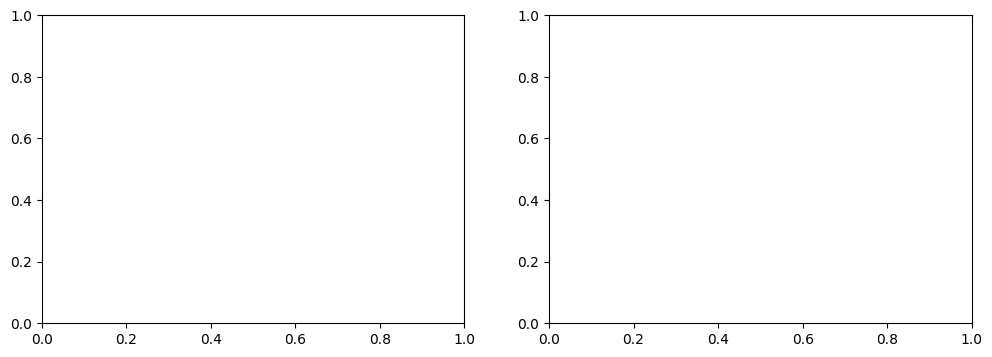

In [ ]:

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], color='steelblue', label='Train Loss')
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history['val_miou'], color='darkorange', label='Val mIoU')
ax2.plot(history['val_dice'], color='green',      label='Val Dice')
ax2.set_title('Validation Metrics'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig('srgcd_training.png', dpi=150)
plt.show()
print('Done. Plot saved to srgcd_training.png')

In [ ]:
# --- Training sanity check ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

ROOT = "Urb3DCD_V1/IEEE_Dataset_V1/1-Lidar05"

# Small dataset for quick test
train_ds = ChangeDetectionDataset(
    root_dir   = os.path.join(ROOT, "TrainNormal-1b"),
    num_samples=2, num_points=128, augment=True
)
train_dl = DataLoader(train_ds, batch_size=2, shuffle=True)

# Model + loss + optimizer
model     = SRGCD().to(DEVICE)
criterion = SRGCDLoss().to(DEVICE)
opt       = torch.optim.AdamW(model.parameters(), lr=1e-3)

# One training epoch (sanity check)
model.train()
for batch in train_dl:
    batch = {k: v.to(DEVICE) for k, v in batch.items()}
    opt.zero_grad()
    out    = model(batch)
    losses = criterion(out, batch)
    losses['total'].backward()
    nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    opt.step()
    print("Batch loss:", losses['total'].item())

print("Training loop executed successfully.")


In [ ]:
#modified code by copilot


In [32]:
def train_srgcd(num_epochs=60, batch_size=2, lr=1e-3, num_points=512):
    train_ds = ChangeDetectionDataset(
        root_dir   = os.path.join(ROOT, "TrainNormal-1b"),
        num_samples=128,
        num_points = num_points,
        seed       = 0,
        augment    = True
    )
    val_ds   = ChangeDetectionDataset(
        root_dir   = os.path.join(ROOT, "Val"),
        num_samples=None,          # use all validation scenes
        num_points = num_points,
        seed       = 99,
        augment    = False
    )
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size)

    model     = SRGCD().to(DEVICE)
    # Use the class-balanced pos_weight computed from the actual label
    # distribution instead of the hardcoded default (fixes collapse).
    criterion = SRGCDLoss(pos_weight=train_ds.pos_weight).to(DEVICE)
    opt       = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched     = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)

    best_miou = 0.0
    history   = {'train_loss': [], 'val_miou': [], 'val_dice': []}

    for epoch in range(1, num_epochs + 1):
        model.train()
        ep_loss = 0.0
        for batch in tqdm(train_dl, desc=f'Ep {epoch}/{num_epochs}', leave=False):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            opt.zero_grad()
            out    = model(batch)
            losses = criterion(out, batch)
            losses['total'].backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            ep_loss += losses['total'].item()

        # Snapshot saving
        if epoch % 2 == 0:
            preds = (torch.sigmoid(out['logits']) > 0.5).long()
            save_progress_images(batch, preds, epoch, 3)
        sched.step()
        avg_loss = ep_loss / len(train_dl)
        history['train_loss'].append(avg_loss)

        model.eval()
        all_p, all_l = [], []
        with torch.no_grad():
            for batch in val_dl:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                out   = model(batch)
                preds = (torch.sigmoid(out['logits']) > 0.5).long()
                all_p.append(preds.cpu().reshape(-1))
                all_l.append(batch['labels'].cpu().reshape(-1))
        p    = torch.cat(all_p).numpy()
        l    = torch.cat(all_l).numpy()
        miou = compute_miou(p, l)
        dice = compute_dice(p, l)
        history['val_miou'].append(miou)
        history['val_dice'].append(dice)

        if miou > best_miou:
            best_miou = miou
            torch.save(model.state_dict(), 'srgcd_best.pth')


        print(f'Epoch {epoch:3d} | Loss {avg_loss:.4f} | mIoU {miou:.4f} | Dice {dice:.4f}')

    print(f'Best val mIoU: {best_miou:.4f}')
    return model, history


In [ ]:
# --- Run ---
ROOT = "Urb3DCD_V1/IEEE_Dataset_V1/1-Lidar05"

trained_model, history = train_srgcd(
    num_epochs = 20,
    batch_size = 4,
    lr         = 1e-3,
    num_points = 512
)

# --- Final evaluation ---
print('\n=== Final Evaluation ===')
test_ds = ChangeDetectionDataset(
    root_dir   = os.path.join(ROOT, "Test"),
    num_samples=32,
    num_points = 512,
    seed       = 777,
    augment    = False
)
test_dl = DataLoader(test_ds, batch_size=4)

trained_model.load_state_dict(torch.load('srgcd_best.pth', map_location=DEVICE))
metrics = evaluate_model(trained_model, test_dl)


Loading 10 scenes | num_points=512 | augment=True
 10 scenes | change ratio: 0.049 | recommended pos_weight: 19.6
Loading 1 scenes | num_points=512 | augment=False
 1 scenes | change ratio: 0.021 | recommended pos_weight: 45.5


Epoch   1 | Loss 0.8692 | mIoU 0.4893 | Dice 0.0000


Epoch   2 | Loss 0.8302 | mIoU 0.4893 | Dice 0.0000


Epoch   3 | Loss 0.8821 | mIoU 0.4893 | Dice 0.0000


Epoch   4 | Loss 0.7436 | mIoU 0.4893 | Dice 0.0000


...

Epoch  18 | Loss 0.7948 | mIoU 0.4893 | Dice 0.0000


Epoch  19 | Loss 0.7086 | mIoU 0.4893 | Dice 0.0000


Epoch  20 | Loss 0.8133 | mIoU 0.4893 | Dice 0.0000
Best val mIoU: 0.4893

=== Final Evaluation ===
Loading 3 scenes | num_points=512 | augment=False
 3 scenes | change ratio: 0.016 | recommended pos_weight: 63.0


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  2.75it/s]

  Unchanged   : Acc=1.0000
  Changed     : Acc=0.0000
  mIoU = 0.4922
  Dice = 0.0000


In [ ]:
# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], color='steelblue', label='Train Loss')
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history['val_miou'], color='darkorange', label='Val mIoU')
ax2.plot(history['val_dice'], color='green',      label='Val Dice')
ax2.set_title('Validation Metrics'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig('srgcd_training.png', dpi=150)
plt.show()
print('Done. Plot saved to srgcd_training.png')

Loading 10 scenes | num_points=2048 | augment=True
 10 scenes | change ratio: 0.050 | recommended pos_weight: 18.9
Loading 1 scenes | num_points=2048 | augment=False
 1 scenes | change ratio: 0.032 | recommended pos_weight: 30.5


Epoch   1 | Loss 0.8066 | mIoU 0.4841 | Dice 0.0000


Epoch   2 | Loss 0.7359 | mIoU 0.4841 | Dice 0.0000


Epoch   3 | Loss 0.7441 | mIoU 0.4841 | Dice 0.0000


Epoch   4 | Loss 0.7535 | mIoU 0.4841 | Dice 0.0000


...

Epoch  18 | Loss 0.7329 | mIoU 0.4841 | Dice 0.0000


Epoch  19 | Loss 0.7305 | mIoU 0.4841 | Dice 0.0000


Epoch  20 | Loss 0.7369 | mIoU 0.4841 | Dice 0.0000
Best val mIoU: 0.4841

=== Final Evaluation ===
Loading 3 scenes | num_points=2048 | augment=False
 3 scenes | change ratio: 0.016 | recommended pos_weight: 62.3


Evaluating: 100%|██████████| 1/1 [00:00<00:00,  6.31it/s]

  Unchanged   : Acc=1.0000
  Changed     : Acc=0.0000
  mIoU = 0.4921
  Dice = 0.0000


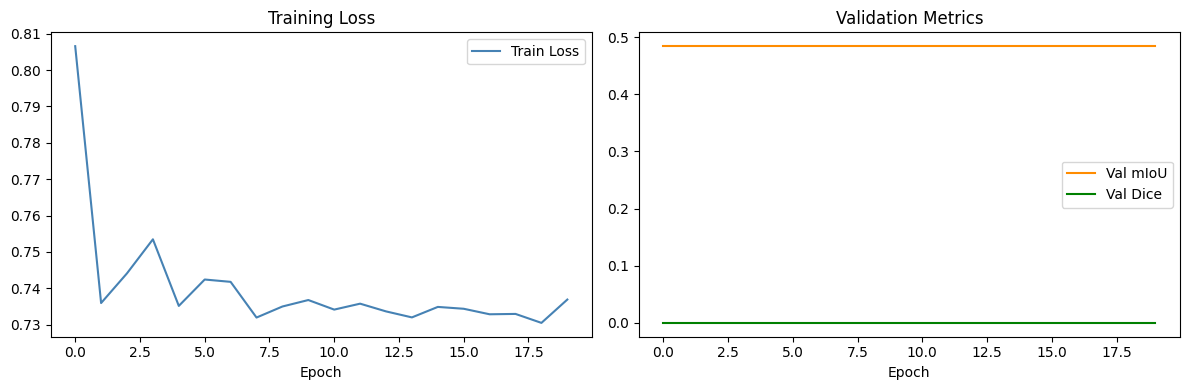

Done. Plot saved to srgcd_training.png


In [33]:
# --- Run ---
ROOT = "Urb3DCD_V1/IEEE_Dataset_V1/1-Lidar05"

trained_model, history = train_srgcd(
    num_epochs = 60,
    batch_size = 2,
    lr         = 1e-3,
    num_points = 2048   # ← increase points per sample
)

# --- Final evaluation ---
print('\n=== Final Evaluation ===')
test_ds = ChangeDetectionDataset(
    root_dir   = os.path.join(ROOT, "Test"),
    num_samples=None,      # ← use all test scenes
    num_points = 2048,
    seed       = 777,
    augment    = False
)
test_dl = DataLoader(test_ds, batch_size=4)

trained_model.load_state_dict(torch.load('srgcd_best.pth', map_location=DEVICE))
metrics = evaluate_model(trained_model, test_dl)

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], color='steelblue', label='Train Loss')
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history['val_miou'], color='darkorange', label='Val mIoU')
ax2.plot(history['val_dice'], color='green',      label='Val Dice')
ax2.set_title('Validation Metrics'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig('srgcd_training.png', dpi=150)
plt.show()
print('Done. Plot saved to srgcd_training.png')


In [28]:
import matplotlib.pyplot as plt

def save_progress_images(batch, preds, epoch, step, out_dir="progress_images"):
    os.makedirs(out_dir, exist_ok=True)
    pts   = batch['feats'][0, :, :3].cpu().numpy()   # xyz coords
    labels= batch['labels'][0].cpu().numpy()
    preds = preds[0].cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12,4))
    axes[0].scatter(pts[:,0], pts[:,1], c=labels, cmap='coolwarm', s=2)
    axes[0].set_title("Ground Truth")

    axes[1].scatter(pts[:,0], pts[:,1], c=preds, cmap='coolwarm', s=2)
    axes[1].set_title(f"Predictions Ep{epoch} Step{step}")

    axes[2].scatter(pts[:,0], pts[:,1], c=(labels==preds), cmap='Greens', s=2)
    axes[2].set_title("Correct vs Wrong")

    plt.tight_layout()
    plt.savefig(f"{out_dir}/progress_ep{epoch}_step{step}.png", dpi=150)
    plt.close()
